In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import optuna
from sklearn.feature_selection import VarianceThreshold,RFE, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, make_scorer, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

In [38]:
fold_1_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/Berniss/Downloads/data/preprocessed/fold_5_val.csv')

In [39]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [40]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [41]:
# Scale using training fold only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [42]:
# Train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict using validation set
y_pred = log_reg.predict(X_val_scaled)

In [45]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        # AUC-PR (best for imbalanced problems)
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        # ROC AUC (optional insight)
        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        # PR Curve
        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0     0.9896    0.9910    0.9903    178711
           1     0.0301    0.0260    0.0279      1920

    accuracy                         0.9807    180631
   macro avg     0.5098    0.5085    0.5091    180631
weighted avg     0.9794    0.9807    0.9800    180631


Confusion Matrix:
[[177100   1611]
 [  1870     50]]

Precision: 0.0301
Recall:    0.0260
F1 Score:  0.0279
AUC-PR (Average Precision): 0.0141
ROC AUC:                   0.5542


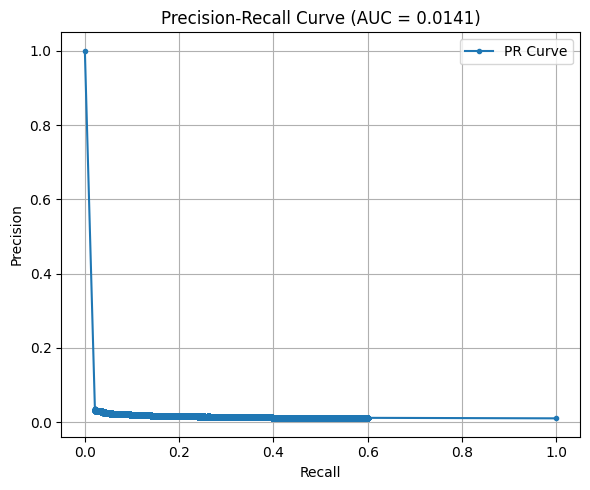

{'precision': 0.030102347983142687,
 'recall': 0.026041666666666668,
 'f1_score': 0.027925160569673275,
 'confusion_matrix': [[177100, 1611], [1870, 50]],
 'auc_pr': 0.014118690010495033,
 'roc_auc': 0.5542039300416128}

In [46]:
y_proba = log_reg.predict_proba(X_val)[:, 1]
y_pred = log_reg.predict(X_val)

evaluate_model(y_val, y_pred, y_proba=y_proba)